In [2]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
from rdkit.Chem.Draw import IPythonConsole
import json
import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdFMCS
from typing import Callable
# import psiresp
# import nglview as nv
import MDAnalysis as mda
import glob
import re
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import display, clear_output
sys.path.append(os.path.abspath("../../espaloma-charge_mod/"))
sys.path.append(os.path.abspath('../')) 
import ResParTools as pt
from espaloma_charge import charge

IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (600, 400)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
!pwd

/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/Lysine_lac


# Протокол расчета парциальных зарядов для модифицированных аминокислот
На вход подаються .smi-файлы мономера и полимеров аминокислоты, где аминокислота входит в состав полимера в положениях N M C. 
У мономера должны бать группы COO<sup>-</sup> и N<sup>+</sup>H<sub>3</sub>. У полимеров соответствующие группы на С и N концах.  

In [5]:
PTM_name = 'Lysine_Benzoyl'
base_name = 'KBO'

## Шаг 1 Открытие .smi-файлов 
Мы рекомендуем использовать словари для записи фаилов молекул, также можно передать путь к  `.smi` в виде строки или листа. На выход вы получите словарь с соответствующими ключами. 

In [19]:
monomer_smi = pt.read_file(f'molecules/K_benzoyl.smi')
# monomer_smi =mon_name.read_file('moleculse/R_CIT.smiles')
trimers_smi = pt.read_file([
                            f'molecules/G_K_benzoyl_G.smi', 
                            # 'moleculse/GRG_CIT.smiles',
                            # 'moleculse/GR_CIT.smiles',

                           ],)
monomer_chem = pt.smi_to_chem(monomer_smi) # RDKit читает smi строку, переводит в chem и добавляет протоны
trimers_chem = pt.smi_to_chem(trimers_smi)
trimers_chem

{'G_K_benzoyl_G': <rdkit.Chem.rdchem.Mol at 0x1553ea6b6260>}

In [20]:
# os.path.basename('moleculse/AKA_1M.smiles').split('.')[0]
mon_name = str(*monomer_smi.keys())
pol_name = str(*trimers_smi.keys())
print(mon_name, pol_name, sep='\n')

K_benzoyl
G_K_benzoyl_G


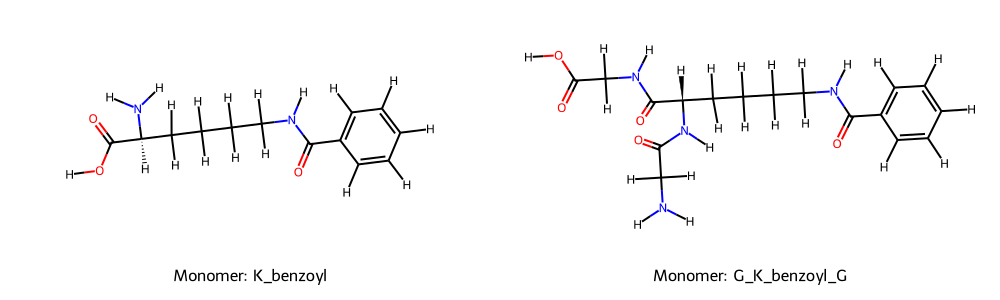

In [21]:
pt.draw_mon_pol_match(monomer_chem | trimers_chem, {}, n_row=2)

## Шаг 2 Поиск подструктур мономера а.к. в полмерах
Наша задача выделить те атомы в составе полимеров, которые входят в состав мономера. Для этого функция `match_mon_to_pol` принимает на вход пару словарей с `Chem` фаилами. Словарь мономеров (один мономер) и полимеров (от 1 до ∞) соответственно. На выход подается словарь с ключами: `substructure`, `mon_pol_matches`, `N_match_atoms`, для кажого из полимеров. \
Где:
- `substructure` - сожердит общие подструктуры мономера и полимера, для каждого из полимеров в формате Chem .
- `mon_pol_matches` - содержит словари соответствия номеров атомов в общей подструктуре с номерами атомов в полимере молекула из общей подструктуры.
- `N_match_atoms` - количество общих атомов для мономера и полимера.\ 
(обычно вам не понадобится этот ключ, но он используется для подсвечивания общей структуры полимера на мономере)

Обратите внимание что набор атомов подструктур внутри мономера различается в зависимости от расположения а.к. в полимере

In [22]:
match_dict = pt.match_mon_to_pol(monomer_chem, trimers_chem, compare_any_bond = False)
# match_dict
print(match_dict.keys(),match_dict['substructure'], sep='\n')

dict_keys(['substructure', 'mon_pol_matches', 'N_match_atoms', 'mon_pol_atom_names'])
{'K_benzoyl': <rdkit.Chem.rdchem.Mol object at 0x1553ea6b66c0>}


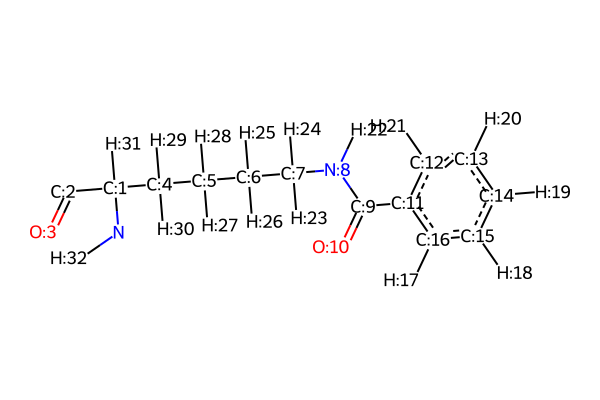

In [23]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

### Отрисовка полученных подструктур на молекулах мономера и полимера
Позволяет убедится в корректности структур

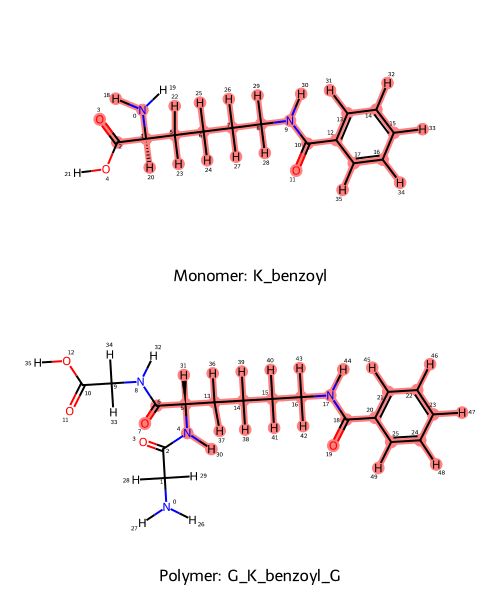

In [24]:
pt.draw_mon_pol_match(monomer_chem, trimers_chem, match_dict, add_small_atom_index=True, prefer_coord_gfen= False)

## Шаг 3 Сохранение молекул подструктур для N M С позиций 

Из молекулы мономера были выделены структуры аминокислот для каждой из позиций `N` `M` `C`. Важно ответить, что при созранение подструктур идет переупордочивание атомов таким образом, что первым атомом в молекуле становится автом **N** в составе аминогруппы. Далее имено они будут использоваться при получении файлов топологии. \
Ниже представленно несколько вариантов сохранения подструктур, но в итоге будут использоватсья файлы формата `.pdb` 

Были получены молекулярные формулы параметризируемых остатков `match_dict['substructure']`. Именно они будут использоваться для получения фаилов топологии в следующем ноутбуке.

#### Сохранение подструктур в виде **smiles**

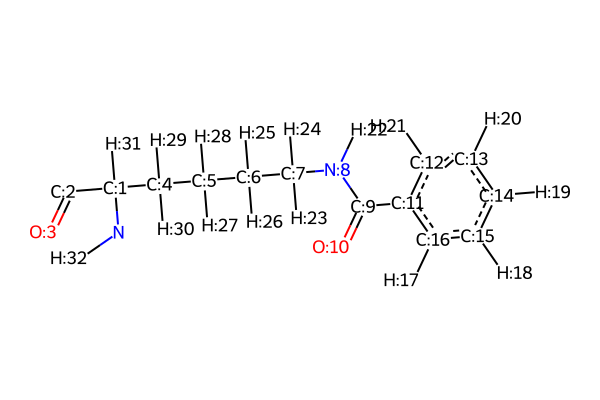

In [25]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

In [26]:
for chem_name, chem_mol in  match_dict['substructure'].items():
    print(chem_name, chem_mol)
    pt.save_aa_chem_to_smiles(chem_mol, f'molecules/substructure/{chem_name}',
                              canonical=False ,make_N_root=False)

K_benzoyl <rdkit.Chem.rdchem.Mol object at 0x1553ea6b66c0>
K_benzoyl.smiles saved to molecules/substructure


##### Проверка сохраненных подструктур

In [32]:
test_smi = pt.read_file([f'molecules/substructure/{mon_name}.smiles',
                        ])
test_chem = pt.smi_to_chem(test_smi, addH=False, sanitize=False)
IPythonConsole.drawOptions.addAtomIndices = False

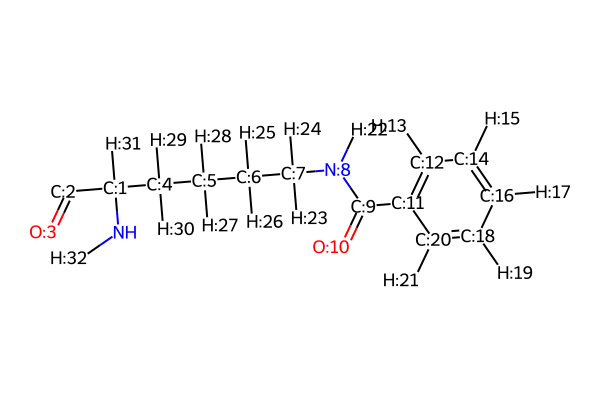

In [33]:
pt.draw_mol_with_atom_index(test_chem[mon_name])

### Сохранение подструктур в виде mol

In [30]:
list_N = []
for sub in match_dict['substructure'].values():
    N_index = pt.find_amino_nitrogen(sub)
    list_N.append(N_index)
print(list_N)
sub_name = ['NR_CIT', 'R_CIT', 'CR_CIT']
for chem_name, chem_mol, root in zip(sub_name, match_dict['substructure'].values(), list_N):
    pt.save_chem_to_mol(chem_mol, f'moleculse/substructure/{chem_name}', rootedAtAtom = root)
    print(chem_name, chem_mol)

10
10
11
[10, 10, 11]
NR_CIT <rdkit.Chem.rdchem.Mol object at 0x7f944627bee0>
R_CIT <rdkit.Chem.rdchem.Mol object at 0x7f944627bf40>
CR_CIT <rdkit.Chem.rdchem.Mol object at 0x7f9480340400>


In [53]:
mol_test = Chem.MolFromMolFile('moleculse/substructure/NR_CIT.mol', sanitize=False,removeHs=False)
# Chem.AddHs(mol_test)

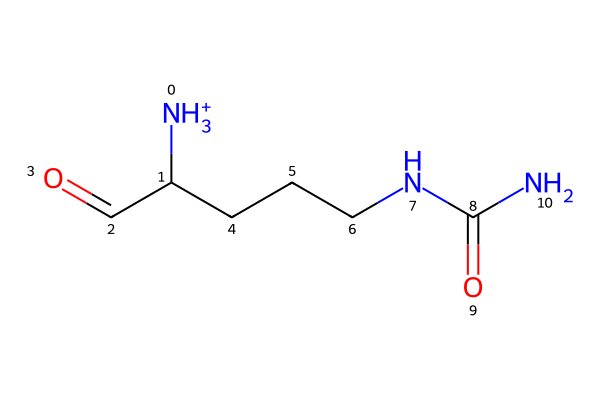

In [54]:
mol_test

In [41]:
IPythonConsole.drawOptions.addAtomIndices = True
mol_test

In [21]:
!pwd

/home/_shared/_projects/2022_md_FRET_nv/param_R_CIT


### Сохранение подструктур в виде **pdb**

То как выглядит подструктура для одного из вариантов позиционирования остатка в цепи:

In [31]:
match_dict

{'substructure': {'K_benzoyl': <rdkit.Chem.rdchem.Mol at 0x1553ea6b66c0>},
 'mon_pol_matches': {'K_benzoyl': {0: 4,
   1: 5,
   2: 6,
   3: 7,
   5: 13,
   6: 14,
   7: 15,
   8: 16,
   9: 17,
   10: 18,
   11: 19,
   12: 20,
   13: 21,
   14: 22,
   15: 23,
   16: 24,
   17: 25,
   35: 49,
   34: 48,
   33: 47,
   32: 46,
   31: 45,
   30: 44,
   28: 42,
   29: 43,
   26: 40,
   27: 41,
   24: 38,
   25: 39,
   22: 36,
   23: 37,
   20: 31,
   18: 30}},
 'N_match_atoms': {'K_benzoyl': 33},
 'mon_pol_atom_names': {'K_benzoyl': None}}

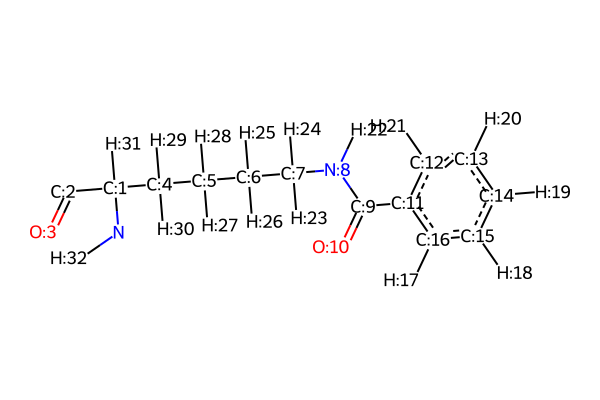

In [29]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

In [30]:
pt.draw_mol_with_atom_index(match_dict['substructure_noH'][mon_name])

KeyError: 'substructure_noH'

In [53]:
new_mol_H = pt.renumber_amino_acid_atoms(match_dict['substructure'][mon_name])
new_mol_no_H = pt.renumber_amino_acid_atoms(match_dict['substructure_noH'][mon_name])

In [54]:
match_dict['substructure'][mon_name] = new_mol_H
match_dict['substructure_noH'][mon_name] = new_mol_no_H

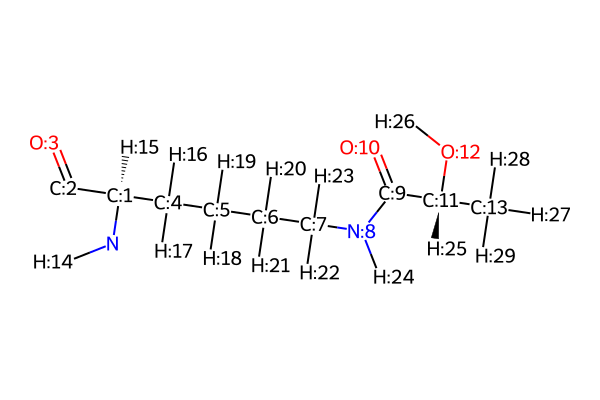

In [55]:
pt.draw_mol_with_atom_index(match_dict['substructure'][mon_name])

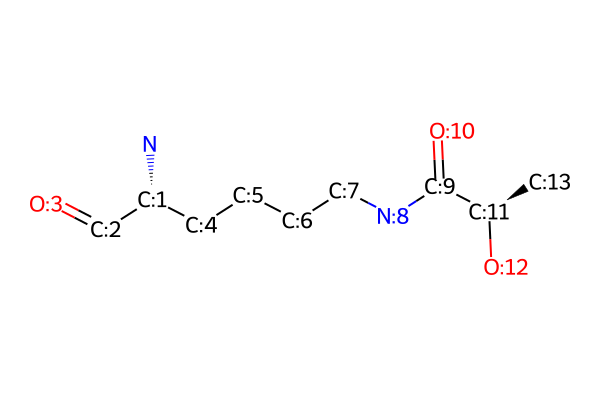

In [56]:
pt.draw_mol_with_atom_index(match_dict['substructure_noH'][mon_name])

Сохранение подструктуры (т.е. атомов входящих в состав модифицированного остатка в зависимости от его позиции в полимере) в формате 
`pdb`. \
Далее полученные ДНК используются для получения парциальных зарядов и для получения файлов топологии. \
Кроме этого вы можете взять их и использовать в молекулярном  моделировании для добавления модифицированного остатка в вашу структуру.   

##### Одиночное сохранение:
Мы сохраняем остаток ак в составе которго атомы только входящие в этот остаток. \
Все имен аатомов уникальные

In [56]:
for chem_name, chem_mol in  match_dict['substructure'].items():
    print(chem_name, chem_mol)
    pt.save_molecule_as_pdb(chem_mol, f'molecules/substructure/{chem_name}',format_coord='2D')

K_benzoyl <rdkit.Chem.rdchem.Mol object at 0x1553ea6b66c0>
Молекула успешно сохранена в файле molecules/substructure/K_benzoyl_2D.pdb в формате 2D.


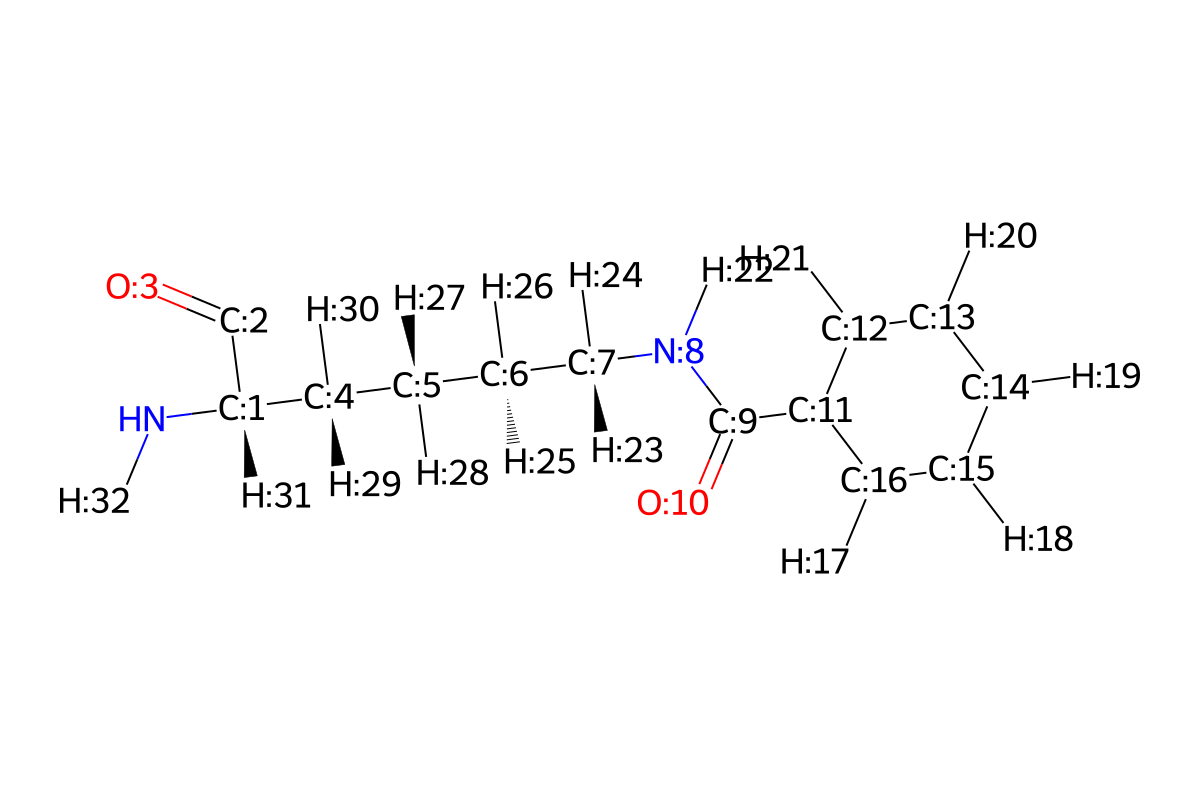

In [57]:
residue = pt.pdb_to_chem(f'molecules/substructure/{mon_name}.pdb')
pt.draw_mol_with_atom_index(residue[mon_name], size = (1200,800))

In [57]:
pt.save_substructure_mol(match_dict, f'molecules/substructure', [mon_name],
                         resname = base_name, resid = 2, segid = 'A')


Уровень 1: 1 атомов
  Буква уровня: B
    CB (бывший) -> CB (индекс 1)
      водород HB1
      водород HB2

Уровень 2: 1 атомов
  Буква уровня: G
    CG (бывший) -> CG (индекс 1)
      водород HG1
      водород HG2

Уровень 3: 1 атомов
  Буква уровня: D
    CD (бывший) -> CD (индекс 1)
      водород HD1
      водород HD2

Уровень 4: 1 атомов
  Буква уровня: E
    CE (бывший) -> CE (индекс 1)
      водород HE1
      водород HE2

Уровень 5: 1 атомов
  Буква уровня: Z
    NZ (бывший) -> NZ (индекс 1)
      водород HZ

Уровень 6: 1 атомов
  Буква уровня: H
    CH (бывший) -> CH (индекс 1)

Уровень 7: 2 атомов
  Буква уровня: T
    OT (бывший) -> OT1 (индекс 1)
    CT (бывший) -> CT2 (индекс 2)
      водород HT2

Уровень 8: 2 атомов
  Буква уровня: I
    OI (бывший) -> OI1 (индекс 1)
      водород HI1
    CI (бывший) -> CI2 (индекс 2)
      водород HI21
      водород HI22
      водород HI23
Дубликаты имен атомов не найдены.
KLA
Lysine_lac.pdb saved to molecules/substructure

Уровень 1: 1 а

[00:38:58] Molecule does not have explicit Hs. Consider calling AddHs()
[00:38:58] Molecule does not have explicit Hs. Consider calling AddHs()
[00:38:58] Molecule does not have explicit Hs. Consider calling AddHs()
[00:38:58] Molecule does not have explicit Hs. Consider calling AddHs()


##### Множественное сохранение:

In [10]:
sub_name = ['NR_CIT_1', 'R_CIT_1', 'CR_CIT_1']
resname_l = ['NRC', 'RC', 'CRC']
for chem_name, chem_mol, resname in zip(sub_name, match_dict['substructure'].values(), resname_l):
    pt.save_aa_chem_to_pdb(chem_mol, f'moleculse/substructure/{chem_name}_rdkit', resname = resname, make_N_root=True)

atom number: 0 became the root atom: 0
Длина atom_names_list не совпадает с количеством атомов в rdkit_mol. Будут использованы стандартные имена атомов.
NR_CIT_1_rdkit.pdb saved to moleculse/substructure


[13:16:38] Molecule does not have explicit Hs. Consider calling AddHs()
[13:16:38] Molecule does not have explicit Hs. Consider calling AddHs()


#### Проверка сохраненных молекул

In [58]:
if '_H' in mon_name:
    mon_name_no_H = mon_name.replace('_H','_no_H')
else:
    mon_name_no_H = mon_name + '_no_H'

In [59]:
# test_pdb = pt.pdb_to_chem(f'Lysine_Cro/molecules/substructure/Kcr_H2.pdb',
test_pdb = pt.pdb_to_chem([
            f'molecules/substructure/{mon_name}.pdb',
            f'molecules/substructure/{mon_name_no_H}.pdb'
              # 'moleculse/substructure/CR_CIT.pdb'
                          ])
test_pdb

{'Lysine_lac': <rdkit.Chem.rdchem.Mol at 0x1553eb791230>,
 'Lysine_lac_no_H': <rdkit.Chem.rdchem.Mol at 0x1553eb44ce40>}

Если все получилось, то вы молжны получить картинку тогоже остатка с такимиже типами связей и количеством атомов. \
В случае если вы использовали `make_N_root=True` последовательность нумерации атомов должна была поменяться и нулевым атомом должен был стать `N` в аминогруппе

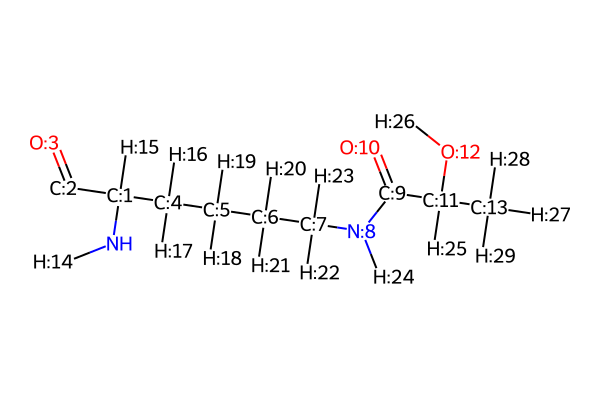

In [60]:
pt.draw_mol_with_atom_index(test_pdb[mon_name])

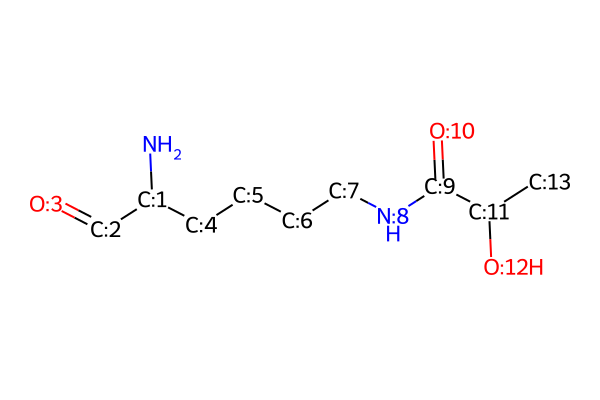

In [61]:
pt.draw_mol_with_atom_index(test_pdb[mon_name_no_H])

##### NGLview отрисовка

Поскольку мы сохранили pdb фаил то можно и через MDAnalysis и nglview посмотреть на него

In [71]:
nv.show_mdanalysis(mda.Universe(f'{PTM_name}/molecules/substructure/{mon_name}.pdb'))

NGLWidget()

## Шаг 4 Переименовка атомов в составе остатка с присвоением канонических имен к каноничным атомам  

Полученные на шаге 3 были полученые структуры остатков. Данные структуры имеют как канонические атомы (т.е. входят в состав каноничных аминокислоты), так и не канонические -- новые. \
На шаге 4 мы находим соствае парметризуемого остатка канонические атомы, которыек сохранилди ориганльные валентности и присваиваем им канонические имена атомов.

In [62]:
# PTM_name = 'Lysine_Cro'
# mon_name = 'Kcr_H'

print(mon_name, pol_name, sep='\n')

Lysine_lac
G_Lysine_lac_G


### Сопоставление модифицированного остатка с референсными остатками

In [63]:
path_to_mod_aa = f'molecules/substructure/{mon_name}.pdb'

mod_aa_name = os.path.basename(path_to_mod_aa).split('.')[0]
print(mod_aa_name)
mod_aa_chem_dict = pt.pdb_to_chem(path_to_mod_aa)

ref_aa_chem_dict, match_data_dict = pt.find_ref_aa(mod_aa_chem_dict, 
                             path_to_ref_mol='../molecules/aminoacids_template',
                             ref_base_name = 'K', only_heavy_mapping = False,
                             match_residue_number = 2, 
                             main_match_data=True, timeout=3)   
ref_aa_chem_dict, match_data_dict

Lysine_lac
Производится сопоставление с Lys
Выполнение Поиск подструктуры между молекулами.  
Поиск подструктуры между молекулами выполнен успешно!
../molecules/aminoacids_template/GKG_H.pdb
Reference amino acid is GKG_H, with 20 matched atoms.


({'GKG_H': <rdkit.Chem.rdchem.Mol at 0x1553eb60bbc0>},
 {'substructure': {'GKG_H': <rdkit.Chem.rdchem.Mol at 0x1553eb44d070>},
  'N_match_atoms': {'GKG_H': 20},
  'mon_pol_matches': {'GKG_H': {14: 10,
    0: 9,
    1: 11,
    15: 12,
    4: 13,
    2: 29,
    16: 14,
    17: 15,
    5: 16,
    3: 30,
    18: 17,
    19: 18,
    6: 19,
    20: 20,
    21: 21,
    7: 22,
    22: 23,
    23: 24,
    8: 25,
    24: 26}},
  'mon_pol_atom_names': {'GKG_H': {'H': 'H',
    'N': 'N',
    'CA': 'CA',
    'HA': 'HA',
    'CB': 'CB',
    'C': 'C',
    'HB1': 'HB1',
    'HB2': 'HB2',
    'CG': 'CG',
    'O': 'O',
    'HG1': 'HG1',
    'HG2': 'HG2',
    'CD': 'CD',
    'HD1': 'HD1',
    'HD2': 'HD2',
    'CE': 'CE',
    'HE1': 'HE1',
    'HE2': 'HE2',
    'NZ': 'NZ',
    'HZ': 'HZ1'}}})

In [38]:
# match_data_dict

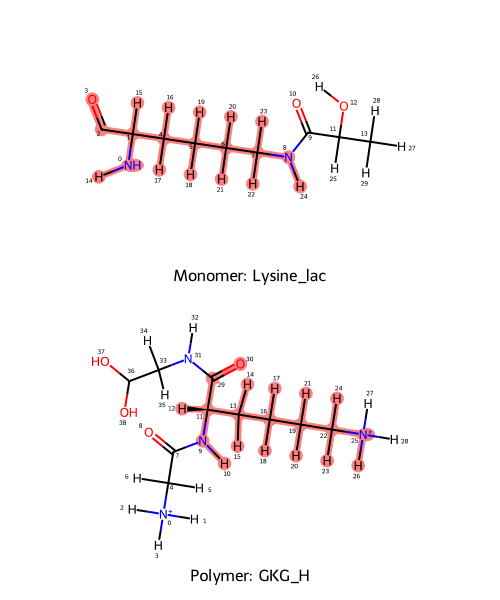

In [64]:
pt.draw_mon_pol_match(mod_aa_chem_dict, ref_aa_chem_dict, match_data_dict, 
                      add_small_atom_index=True, prefer_coord_gfen = False)

In [65]:
pt.save_json('general_atoms', list(*match_data_dict['mon_pol_atom_names'].values()), )

Файл успешно сохранен: 
/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/Lysine_lac/general_atoms.json


#### Переименовка атомов в модифицированном остатке

In [31]:
key_map = next(iter(match_data_dict['mon_pol_matches'].keys()))
match_data_dict['mon_pol_matches'][key_map]

{69: 10, 0: 9, 1: 11, 68: 12, 4: 13, 2: 18, 70: 14, 71: 15, 5: 16, 3: 19}

In [67]:
modifie_residue = pt.add_names_from_residue(mod_aa_chem_dict,
                       match_data_dict,
                        resid = 2,
                        resname = base_name,)

Дубликаты имен атомов не найдены.


In [68]:
save_molecule_as_pdb(modifie_residue, f'molecules/substructure/{PTM_name}_rn.pdb', format_coord='3D')

NameError: name 'save_molecule_as_pdb' is not defined

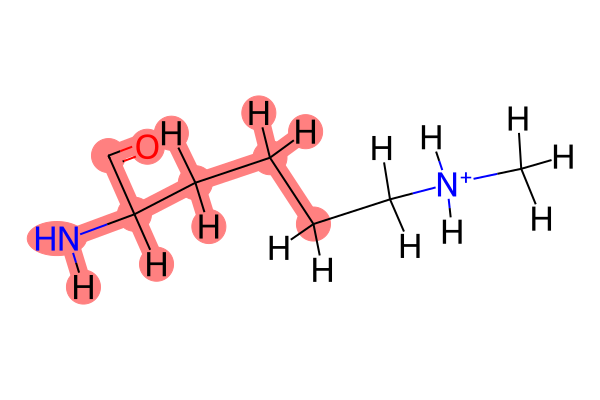

In [32]:
modifie_residue

### Шаг 4.1. Протонирование атомов, потерявших стандартную валентность 

Этот шаг необходим для дальнейшего получения файла itp для нашей а.к. \
Дело в том, что acpype отказывается создавать топологию для атомов с нестандартными валентностями, что вполне логично. Поэтому мы добавляем протоны, которых на самом деле нет в остатке. После в процесе редактирвоания itp мы удалим все строки с лишними протонами. \
Стоит отметить, что этот шаг можно также выполнить с использованием любого удобного вам молекулярного редактора (ChimeraX, PyMOL) взяв за основу pdb фаийл сохраненный на 3-ем шаге.

In [69]:
H_modifie_residue = pt.add_protons_and_renumber_H(modifie_residue, resname = base_name, resid=2, segid='A')

Для атома 30 присвоено имя HW1
Для атома 31 присвоено имя HW2


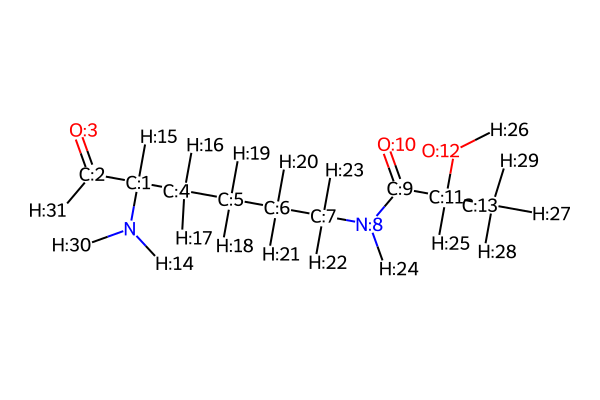

In [70]:
pt.draw_mol_with_atom_index(H_modifie_residue)

In [71]:
for atom in H_modifie_residue.GetAtoms():
    info = atom.GetPDBResidueInfo()
    print(info.GetResidueNumber(), info.GetResidueName(), atom.GetProp('AtomName'), atom.GetIdx(), atom.GetAtomMapNum())

2 KLA N 0 0
2 KLA CA 1 1
2 KLA C 2 2
2 KLA O 3 3
2 KLA CB 4 4
2 KLA CG 5 5
2 KLA CD 6 6
2 KLA CE 7 7
2 KLA NZ 8 8
2 KLA CH 9 9
2 KLA OT1 10 10
2 KLA CT2 11 11
2 KLA OI1 12 12
2 KLA CI2 13 13
2 KLA H 14 14
2 KLA HA 15 15
2 KLA HB1 16 16
2 KLA HB2 17 17
2 KLA HG1 18 18
2 KLA HG2 19 19
2 KLA HD1 20 20
2 KLA HD2 21 21
2 KLA HE1 22 22
2 KLA HE2 23 23
2 KLA HZ 24 24
2 KLA HT2 25 25
2 KLA HI1 26 26
2 KLA HI21 27 27
2 KLA HI22 28 28
2 KLA HI23 29 29
2 KLA HW1 30 30
2 KLA HW2 31 31


In [72]:
pt.save_molecule_as_pdb(H_modifie_residue, f'molecules/substructure/{PTM_name}_rn_H.pdb', format_coord='3D')

Молекула успешно сохранена в файле molecules/substructure/Lysine_lac_rn_H_3D.pdb в формате 3D.


In [73]:
pt.save_aa_chem_to_smiles(H_modifie_residue, f'molecules/substructure/{chem_name}_rn_H.smiles', canonical=False ,make_N_root=False)

Lysine_lac_rn_Hles.smiles saved to molecules/substructure


In [37]:
test = mda.Universe(f'{PTM_name}/molecules/substructure/{PTM_name}_rn_H_3D.pdb')
nv.show_mdanalysis(test)

NGLWidget()

## Шаг 5. Расчет зарядов при помощи библиотеки Espaloma Charge

На вход: 
- Молекула-ы в виде тримеров в формате smiles. 

Задача ограничейни зарядов для одной молекулы


Создание ограничений

In [34]:
!pwd

/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/Lysine_Benzoyl


In [35]:
PTM_name

'Lysine_Benzoyl'

In [41]:
mon_name

'K_benzoyl'

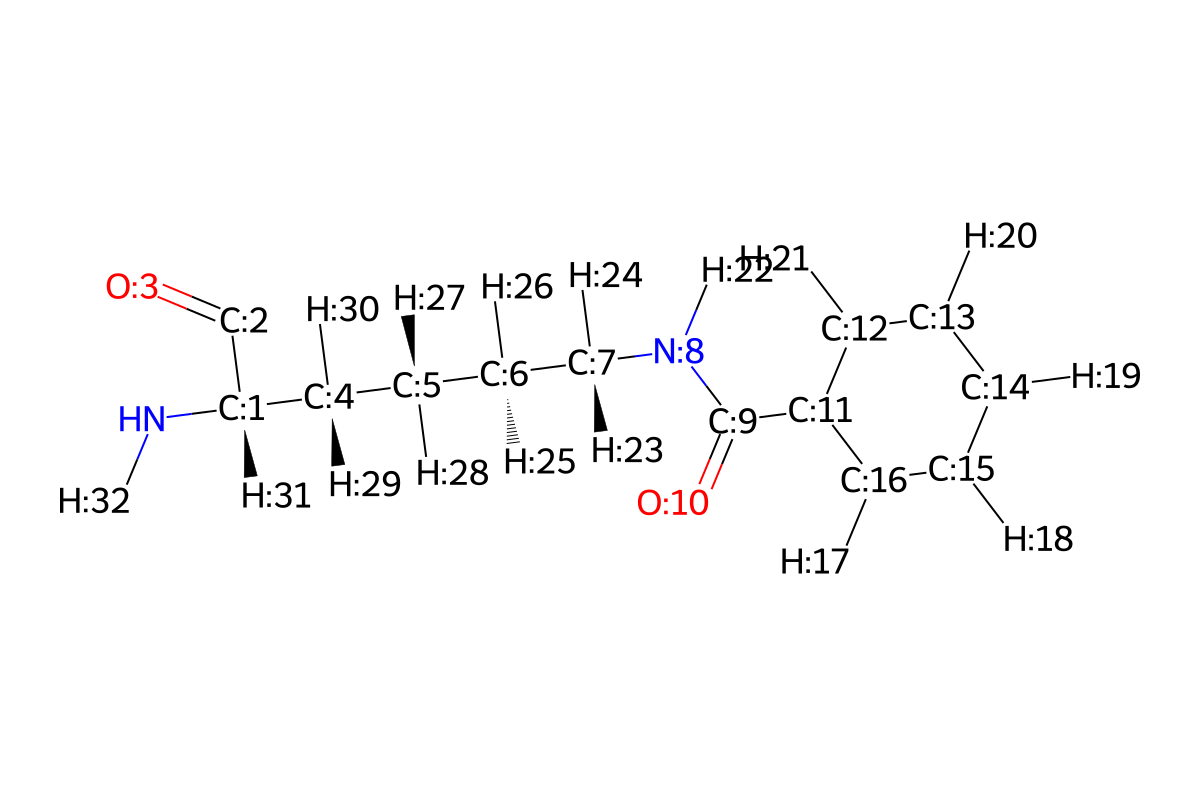

In [43]:
residue = pt.pdb_to_chem(f'molecules/substructure/{mon_name}.pdb')
pt.draw_mol_with_atom_index(residue[mon_name], size = (1200,800))

In [77]:
constraint_dict = {f'{mon_name}':
                  {'symmetric_list': [],
                   'charge_atom_dict': {0:-0.34790, 15:0.27470, 
                                        1:-0.24000, 2:0.73410, 
                                        3:-0.58940, 14:0.14260},
                   'charge_of_monomer': 0.0000,
                  }
                  }

### Расчет зарядов при помощи библиотеки Espaloma Charge

In [83]:
charges = charge(residue[mon_name], 
                 constraints=constraint_dict[mon_name]['charge_atom_dict']
                )

print(f'Суммарный заряд молекулы: {sum(charges)}', charges, sep = '\n')
print(round(pt.calculate_true_sum(charges),5))

Суммарный заряд молекулы: -4.852190613746643e-07
[-0.3479     -0.24        0.7341     -0.5894     -0.19495678 -0.20988493
 -0.20256695 -0.00388346 -0.61488056  0.38150054 -0.4822674  -0.04344647
 -0.73523206 -0.35859707  0.1426      0.2747      0.14171243  0.14171243
  0.13967608  0.13967606  0.14945146  0.14945146  0.11691327  0.11691327
  0.37381527  0.16579817  0.39530724  0.15322918  0.15322918  0.15322918]
-0.00000


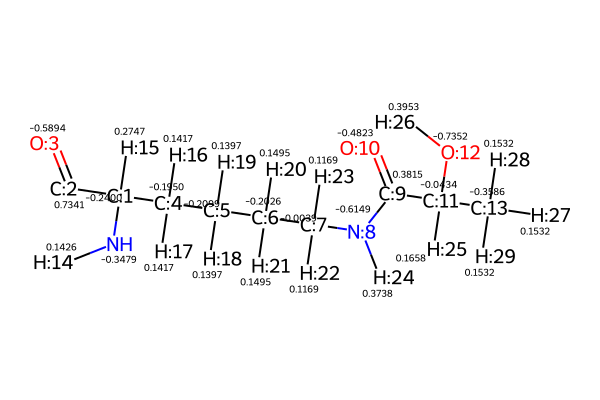

In [79]:
pt.draw_mol_with_atom_index(residue[mon_name], charge_list=charges)

## Сохранение масcива зарядов

In [84]:
pt.save_charges_json(name = f'AI_chrges', charge_list = charges.tolist(),  )

Файл успешно сохранен: 
/trinity/home/_shared/_projects/2022_md_FRET_nv/AI_param_tool/notebooks_and_examples/Lysine_lac/AI_chrges_Lysine_lac.json
